In [2]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import json

import numpy as np
import healpy as hp

import jax.numpy as jnp

wdir = "/n/home07/yitians/fermi/fermi-prob-prog/production"
sys.path.append(f"{wdir}/..")
from models.np_model_gc import NPModelGC11, NPModelGC17, NPModelGC2, NPModelGC2SCF, NPModelGC7, NPModelGCFull

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#===== DIRS =====#
wdir = "/n/home07/yitians/fermi/fermi-prob-prog/production"
data_dir = f"{wdir}/../outputs/simulations"
save_dir = f"{wdir}/../outputs/fit/svi_gcfull_gcfull_deltapsf_0930"
os.makedirs(save_dir, exist_ok=True)

#===== MASK & DATA =====#
mask_roi = jnp.load(f"{wdir}/mask_roi.npy")
mask_norm = jnp.load(f"{wdir}/mask_norm.npy")

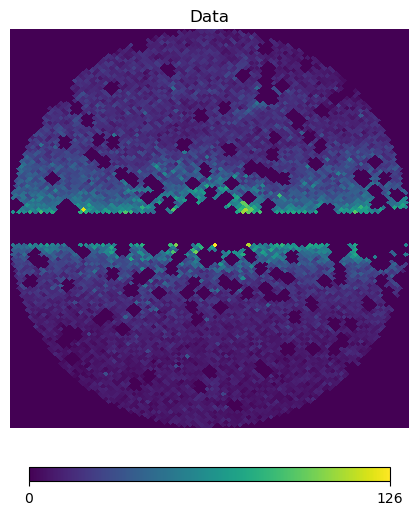

In [8]:
data = np.load(f"{data_dir}/sim_gcfull_deltapsf_n100.npy")[0]
data_full = np.zeros(hp.nside2npix(128))
data_full[~mask_norm] = data
data_in = np.array(data_full, dtype=jnp.int32)
data_in[mask_roi] = 0

# hp.cartview(np.clip(data_in, 0.5, None), title="Data", cbar=True, lonra=[-25, 25], latra=[-25, 25], norm="log")
hp.cartview(data_in, title="Data", cbar=True, lonra=[-25, 25], latra=[-25, 25])

In [8]:
m = NPModelGCFull(psf_tags=['deltasimple'], data=data_in)

Number of pixels in ROI: 6839
Using PSF tags: ['deltasimple']
Max photon count is 158


In [10]:
from models.scd import dnds
from likelihoods.npll_jax_new import log_like_np

In [11]:
data = data_in
mu = jnp.zeros_like(data)

# poissonian fixed (14): pib*3 ics*3 iso bub psc blg*5
S_pib_s = [14., 0., 0.,]
S_ics_s = [6, 0, 0]
S_iso = 3
S_bub = 2
S_psc = 4
S_blg_s = [
    4, 5, 4, 5, 4
]

nm = m.normalization_mask
for i in range(3):
    mu += S_pib_s[i] * m.pib[i] / jnp.mean(m.pib[i][~nm])
    mu += S_ics_s[i] * m.ics[i] / jnp.mean(m.ics[i][~nm])
mu += S_iso * m.temp_iso / jnp.mean(m.temp_iso[~nm])
mu += S_bub * m.temp_bub / jnp.mean(m.temp_bub[~nm])
mu += S_psc * m.temp_psc / jnp.mean(m.temp_psc[~nm])
for i in range(5):
    mu += S_blg_s[i] * m.bulge_templates[i] / jnp.mean(m.bulge_templates[i][~nm])

# poissonian variable (2): nfw
S_nfw = 4
gamma_poiss = 1.3
temp_nfw_poiss = m.nfw_template.get_NFW2_template(gamma=gamma_poiss)
mu += S_nfw * temp_nfw_poiss / jnp.mean(temp_nfw_poiss[~nm])

# non-poissonian: gce (7) + (5) dsk (3) + (5)
Sps_nfw = 3.
gamma_ps = 1.
temp_nfw_ps = m.nfw_template.get_NFW2_template(gamma=gamma_ps)
temp_gce_ps = Sps_nfw * temp_nfw_ps / jnp.mean(temp_nfw_ps[~nm])

Sps_blg_s = [
    3, 4, 3, 4, 3
]
for i in range(5):
    temp_gce_ps += Sps_blg_s[i] * m.bulge_templates[i] / jnp.mean(m.bulge_templates[i][~nm])
Sps_gce = jnp.mean(temp_gce_ps[~nm]) # definition of Sps_gce
temp_gce_ps = temp_gce_ps / Sps_gce

Sps_dsk = 3.
zs = 0.6
C = 6.
temp_dsk_ps = m.disk_template.get_template(zs=zs, C=C)
temp_dsk_ps = temp_dsk_ps / jnp.mean(temp_dsk_ps[~nm])

npt_compressed = jnp.array([temp_gce_ps[~m.mask_roi], temp_dsk_ps[~m.mask_roi]])

theta = []
for ps in ["gce", "dsk"]:
    Sps = Sps_gce if ps == "gce" else Sps_dsk
    n1 = 5.
    n2 = 1.5
    n3 = -5.5
    sb1 = 10
    lambda_s = 0.5

    theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
    s_ary = jnp.logspace(-1., 2., 1000)
    dnds_ary = dnds(s_ary, theta_tmp)
    num_photon_for_unit_theta0 = jnp.trapz(s_ary * dnds_ary, s_ary)
    theta.append([Sps / num_photon_for_unit_theta0, n1, n2, n3, sb1, lambda_s * sb1])
theta = jnp.array(theta)

ll = log_like_np(
    theta=theta,
    pt_sum_compressed=mu[~m.mask_roi],
    npt_compressed=npt_compressed,
    data=data[~m.mask_roi],
    f_ary=m.f_ary,
    df_rho_ary=m.df_rho_ary,
    k_max=m.k_max,
    npixROI=m.npixROI,
)

with numpyro.plate('data', self.npixROI):
    with handlers.mask(mask=~jnp.logical_or(jnp.isinf(ll), jnp.isnan(ll))):
        return numpyro.factor('ll', ll)

In [17]:
jnp.sum(jnp.isinf(jnp.nan_to_num(ll)))

Array(0, dtype=int64)

In [19]:
jnp.nan_to_num(-jnp.inf)

Array(-1.79769313e+308, dtype=float64)